#### To Do:

- fix with Amelie that the names are the same of all the files: easier! 
- How to control for noise ==> curve_4 => noise after sec 6 (i think) -> how to fix it?
- link segment time with angle time !! -> fix data qtm: naming + conversion to opensim: GRF included: easier to calculate contact time

In [1]:
# load the project root into the notebook to be able to load functions from other modules
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "tests":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent

sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from scipy.io import loadmat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os 
from Base.Opensim_analysis_code import angle_plot, analyze_folder_OS, merge_left_contacts, get_angle_data
from Base.GRF_analysis_code import analyze_folder_segm

print(os.getcwd())

/Users/ernstdavidts/Library/CloudStorage/OneDrive-UGent/Master I/Oslo/Curved_Running_Pilot/Base/tests
/Users/ernstdavidts/Library/CloudStorage/OneDrive-UGent/Master I/Oslo/Curved_Running_Pilot/Base/tests
/Users/ernstdavidts/Library/CloudStorage/OneDrive-UGent/Master I/Oslo/Curved_Running_Pilot/Base/tests


In [3]:
folder = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), "files")
df_segm = analyze_folder_segm(folder)
# df = get_angle_data("../../files/OpenSim3/MOD_ED_Shoe25OpenSim_python.mat")
# trial_angle = df["ANGLES_TABLE"][0, 0]
# labels = df["labels"][0,0][0][0][0][0][0]
# trial_dict = {}
# for name in trial_angle.dtype.names:
#     print(name)
#     values = trial_angle[name]
    
#     for i in range(len(values[0,:])):
#         trial_dict[name] = pd.DataFrame(values, columns=labels)


# labels = df["labels"][0,0][0][0][0][0][0]
# for i in range(len(labels)):
#     label = 
#     print(label)

# df.keys()
# tryout1 = loadmat("../../files/NEW_Shoe25OpenSim.mat")
# tryout2 = loadmat("../../files/NEW_MN_Shoe25OpenSim_FULL.mat")

# #print(tryout1["ANGLES_TABLE"][0,0])
# angles2 = tryout2["ANGLES_TABLE"][0,0]
# tryout2["GRF_TABLE"][0,0][0][:,5]


In [4]:
OS3 = analyze_folder_OS("../../files/OpenSim3")
left_contacts = df_segm[df_segm["plate"] == "FP1"].copy()
left_contacts["participant"] = left_contacts["participant"].replace({
    "01": "ED",
    "02": "MN"
})

left_contacts["condition"] = left_contacts["condition"].str.capitalize()
left_contacts["trial"] = left_contacts["trial"].astype(str)
left_contacts["shoe"] = left_contacts["shoe"].astype(str)

OS_stance_left3 = {}
for key in OS3:
    if key.endswith("_r"):
        continue

    angle_df = OS3[key].copy()
    angle_df_stance = merge_left_contacts(angle_df, left_contacts)
    OS_stance_left3[key] = angle_df_stance
OS_stance_left3

{np.str_('pelvis_tilt'):      participant shoe condition trial  time     value  side        IC  \
 1             ED   25     Curve     1  0.01  9.646430  None  0.003333   
 2             ED   25     Curve     1  0.02  9.286689  None  0.003333   
 3             ED   25     Curve     1  0.03  8.848503  None  0.003333   
 4             ED   25     Curve     1  0.04  8.050588  None  0.003333   
 5             ED   25     Curve     1  0.05  7.193662  None  0.003333   
 ...          ...  ...       ...   ...   ...       ...   ...       ...   
 4331          MN   25  Straight     5  0.19  3.413654  None  0.041000   
 4332          MN   25  Straight     5  0.20  4.013533  None  0.041000   
 4333          MN   25  Straight     5  0.21  4.427069  None  0.041000   
 4334          MN   25  Straight     5  0.22  4.807557  None  0.041000   
 4335          MN   25  Straight     5  0.23  5.144447  None  0.041000   
 
             TO  
 1     0.223333  
 2     0.223333  
 3     0.223333  
 4     0.22333

In [5]:
OS = analyze_folder_OS("../../files/OpenSim")
left_contacts = df_segm[df_segm["plate"] == "FP1"].copy()
left_contacts["participant"] = left_contacts["participant"].replace({
    "01": "ED",
    "02": "MN"
})

left_contacts["condition"] = left_contacts["condition"].str.capitalize()
left_contacts["trial"] = left_contacts["trial"].astype(str)
left_contacts["shoe"] = left_contacts["shoe"].astype(str)

OS_stance_left = {}
for key in OS:
    if key.endswith("_r"):
        continue

    angle_df = OS[key].copy()
    angle_df_stance = merge_left_contacts(angle_df, left_contacts)
    OS_stance_left[key] = angle_df_stance
OS_stance_left

{np.str_('pelvis_tilt'):      participant shoe condition trial  time      value  side     IC     TO
 3             MN   45     Curve     1  0.03  12.377235  None  0.029  0.223
 4             MN   45     Curve     1  0.04  11.854617  None  0.029  0.223
 5             MN   45     Curve     1  0.05  11.388025  None  0.029  0.223
 6             MN   45     Curve     1  0.06  11.037579  None  0.029  0.223
 7             MN   45     Curve     1  0.07  11.024537  None  0.029  0.223
 ...          ...  ...       ...   ...   ...        ...   ...    ...    ...
 4343          MN   55  Straight     5  0.24   2.807599  None  0.094  0.280
 4344          MN   55  Straight     5  0.25   3.173681  None  0.094  0.280
 4345          MN   55  Straight     5  0.26   3.461483  None  0.094  0.280
 4346          MN   55  Straight     5  0.27   3.871756  None  0.094  0.280
 4347          MN   55  Straight     5  0.28   4.408137  None  0.094  0.280
 
 [1250 rows x 9 columns],
 np.str_('pelvis_list'):      partic

In [6]:
OS2 = analyze_folder_OS("../../files/OpenSim2")
left_contacts = df_segm[df_segm["plate"] == "FP1"].copy()
left_contacts["participant"] = left_contacts["participant"].replace({
    "01": "ED",
    "02": "MN"
})

left_contacts["condition"] = left_contacts["condition"].str.capitalize()
left_contacts["trial"] = left_contacts["trial"].astype(str)
left_contacts["shoe"] = left_contacts["shoe"].astype(str)

OS_stance_left2 = {}
for key in OS2:
    if key.endswith("_r"):
        continue

    angle_df = OS2[key].copy()
    angle_df_stance = merge_left_contacts(angle_df, left_contacts)
    OS_stance_left2[key] = angle_df_stance
OS_stance_left2

{np.str_('pelvis_rotation'):      participant shoe condition trial  time      value  side        IC  \
 1             ED   25     Curve     1  0.01  78.996462  None  0.003333   
 2             ED   25     Curve     1  0.02  79.687952  None  0.003333   
 3             ED   25     Curve     1  0.03  80.551433  None  0.003333   
 4             ED   25     Curve     1  0.04  81.634575  None  0.003333   
 5             ED   25     Curve     1  0.05  82.783502  None  0.003333   
 ...          ...  ...       ...   ...   ...        ...   ...       ...   
 4331          MN   25  Straight     5  0.19  94.017621  None  0.041000   
 4332          MN   25  Straight     5  0.20  93.700397  None  0.041000   
 4333          MN   25  Straight     5  0.21  93.612601  None  0.041000   
 4334          MN   25  Straight     5  0.22  93.532055  None  0.041000   
 4335          MN   25  Straight     5  0.23  93.545432  None  0.041000   
 
             TO  
 1     0.223333  
 2     0.223333  
 3     0.223333 

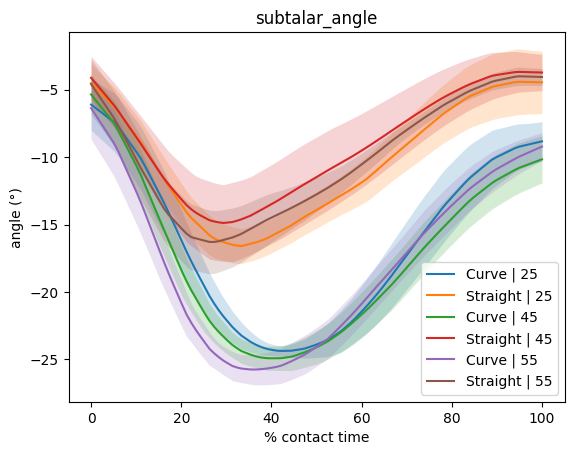

In [14]:
angle_plot(OS_stance_left3, joint= "subtalar_angle", comparison= ["condition", "shoe"], side="l", participant="MN")

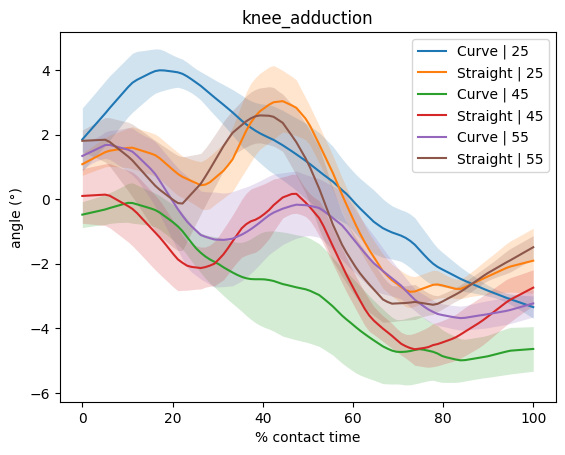

In [8]:
angle_plot(OS_stance_left2, joint= "knee_adduction", comparison= ["condition", "shoe"], side="l", participant="MN")

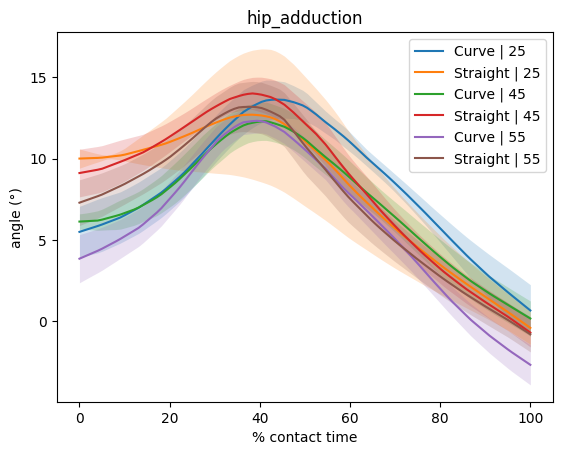

In [10]:
angle_plot(OS_stance_left, joint= "hip_adduction", comparison= ["condition", "shoe"], side="l", participant="ED")